In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error,root_mean_squared_error, mean_absolute_percentage_error,r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

In [2]:
df= joblib.load(r'C:\Users\MINE\Desktop\Air passenger prediction\dataset\df.pkl')

In [3]:
print(df.shape)
df.head()

(118, 10)


,#Passengers,month,quater,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6
Month,,,,,,,,,,
1949-01-01,112,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-02-01,118,2,1,112.0,NaN,NaN,NaN,NaN,NaN,NaN
1949-03-01,132,3,1,118.0,112.0,NaN,120.666667,10.263203,NaN,NaN
1949-04-01,129,4,2,132.0,118.0,112.0,126.333333,7.371115,NaN,NaN
1949-05-01,121,5,2,129.0,132.0,118.0,127.333333,5.686241,NaN,NaN


In [4]:
df.asfreq('MS')
df.reset_index(inplace=True)
df.Month = pd.to_datetime(df.Month)
df.set_index('Month', inplace=True)
df.sort_index(inplace=True)
df.index.dtype


dtype('<M8[ns]')

In [5]:

print(df.shape)
df.head()

(118, 10)


,#Passengers,month,quater,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6
Month,,,,,,,,,,
1949-01-01,112,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-02-01,118,2,1,112.0,NaN,NaN,NaN,NaN,NaN,NaN
1949-03-01,132,3,1,118.0,112.0,NaN,120.666667,10.263203,NaN,NaN
1949-04-01,129,4,2,132.0,118.0,112.0,126.333333,7.371115,NaN,NaN
1949-05-01,121,5,2,129.0,132.0,118.0,127.333333,5.686241,NaN,NaN


In [6]:
print(df.isnull().sum())
print(df.duplicated().sum())

#Passengers      0
month            0
quater           0
lag1             1
lag2             2
lag3             3
rolling_mean3    2
rolling_std3     2
rolling_mean6    5
rolling_std6     5
dtype: int64
0


In [7]:
df.fillna(method='bfill', inplace=True)

C:\Users\MINE\AppData\Local\Temp\ipykernel_9072\3314729575.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


In [8]:
print(df.shape)
print(df.info())
df.head()

(118, 10)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 118 entries, 1949-01-01 to 1960-12-01
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   #Passengers    118 non-null    int64  
 1   month          118 non-null    int32  
 2   quater         118 non-null    int32  
 3   lag1           118 non-null    float64
 4   lag2           118 non-null    float64
 5   lag3           118 non-null    float64
 6   rolling_mean3  118 non-null    float64
 7   rolling_std3   118 non-null    float64
 8   rolling_mean6  118 non-null    float64
 9   rolling_std6   118 non-null    float64
dtypes: float64(7), int32(2), int64(1)
memory usage: 9.2 KB
None


,#Passengers,month,quater,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6
Month,,,,,,,,,,
1949-01-01,112,1,1,112.0,112.0,112.0,120.666667,10.263203,124.5,8.916277
1949-02-01,118,2,1,112.0,112.0,112.0,120.666667,10.263203,124.5,8.916277
1949-03-01,132,3,1,118.0,112.0,112.0,120.666667,10.263203,124.5,8.916277
1949-04-01,129,4,2,132.0,118.0,112.0,126.333333,7.371115,124.5,8.916277
1949-05-01,121,5,2,129.0,132.0,118.0,127.333333,5.686241,124.5,8.916277


In [9]:
train,test= df.iloc[:-12,:], df.iloc[-12:,:]

x_train,y_train= train.drop(columns=['#Passengers']), train['#Passengers']
x_test,y_test= test.drop(columns=['#Passengers']), test['#Passengers']

In [10]:
print(x_train.shape)
print(x_train.isnull().sum())
x_train.head()


(106, 9)
month            0
quater           0
lag1             0
lag2             0
lag3             0
rolling_mean3    0
rolling_std3     0
rolling_mean6    0
rolling_std6     0
dtype: int64


,month,quater,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6
Month,,,,,,,,,
1949-01-01,1,1,112.0,112.0,112.0,120.666667,10.263203,124.5,8.916277
1949-02-01,2,1,112.0,112.0,112.0,120.666667,10.263203,124.5,8.916277
1949-03-01,3,1,118.0,112.0,112.0,120.666667,10.263203,124.5,8.916277
1949-04-01,4,2,132.0,118.0,112.0,126.333333,7.371115,124.5,8.916277
1949-05-01,5,2,129.0,132.0,118.0,127.333333,5.686241,124.5,8.916277


In [11]:
simple_model= XGBRegressor(random_state= 42)

simple_model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [12]:
simple_pred= simple_model.predict(x_test)
simple_pred= pd.Series(simple_pred, index= y_test.index)

In [13]:
simple_pred

Month
1959-09-01    489.310974
1959-10-01    356.566711
1960-01-01    414.044617
1960-02-01    389.163239
1960-03-01    415.617523
1960-04-01    413.325287
1960-06-01    480.863831
1960-07-01    548.200317
1960-08-01    558.998718
1960-09-01    489.501343
1960-11-01    438.812592
1960-12-01    318.292938
dtype: float32

In [14]:
def model_evaluator(train,test,predictions, model:str):
  plt.figure(figsize=(10,4))
  plt.plot(train,label='train')
  plt.plot(test,label='test')
  plt.plot(predictions,label='Prediction')

  plt.legend(loc='best')
  plt.title(f'Forecast with {model}')
  plt.show()

  mae= round(mean_absolute_error(test,predictions), 2)
  mape= round(mean_absolute_percentage_error(test, predictions), 2) * 100
  r2= round(r2_score(test, predictions), 2)
  rmse= round(root_mean_squared_error(test,predictions), 2)

  print(f'mean absolute error: {mae}')
  print(f'mean absolute percentage error: {mape}%')
  print(f'r2 score: {r2}')
  print(f'root mean squared error: {rmse}')
  values= {'mae': mae, 'mape': mape, 'r2': r2, 'rmse': rmse}
  value= pd.DataFrame(values, index=[0])
  return value

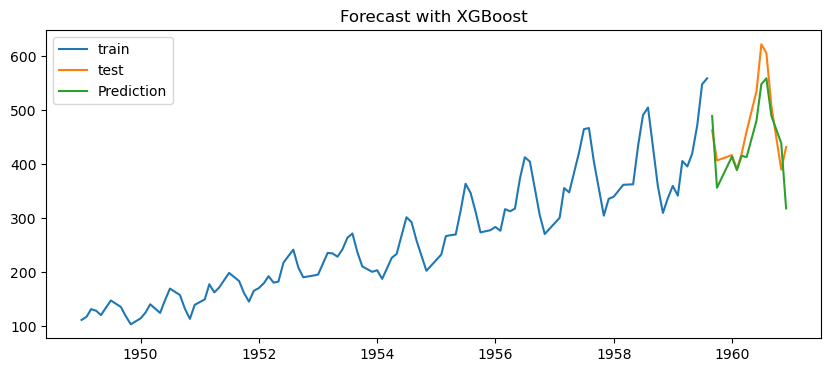

mean absolute error: 40.71
mean absolute percentage error: 9.0%
r2 score: 0.55
root mean squared error: 51.46


,mae,mape,r2,rmse
0,40.71,9.0,0.55,51.46


In [15]:
model_evaluator(y_train,y_test,simple_pred, 'XGBoost')

In [16]:
# Fine tuning xgboost

tscv = TimeSeriesSplit(n_splits=5)
 
param_dist = {
    "n_estimators": list(range(100, 2000, 50)),                 # 100, 150, ..., 1000
    "max_depth": list(range(2, 9,2)),                              # 2, 3, ..., 8
    "learning_rate": list(np.arange(0.005, 0.305, 0.1)),        # 0.005 -> 0.3
    "subsample": list(np.arange(0.5, 1.0, 0.2)),               # 0.5 -> 1.0
    "colsample_bytree": list(np.arange(0.5, 1.0, 0.2)),        # 0.5 -> 1.0
    "min_child_weight": list(range(1, 11,2)),                      # 1, 2, ..., 10
    "gamma": list(np.arange(0.0, 0.51, 0.1)),                   # 0 -> 0.5
    "reg_alpha": list(np.arange(0.0, 1.01, 0.1)),                # 0 -> 1.0
    "reg_lambda": list(np.arange(0.0, 2.01, 0.1)),               # 0 -> 2.0
}
 
xgb_model =XGBRegressor(
    objective="reg:squarederror",
    random_state=42,

)

 

In [17]:
grid= RandomizedSearchCV(xgb_model, param_dist, cv=tscv, n_jobs=-1, verbose=1,scoring="neg_root_mean_squared_error",)

In [18]:
grid.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamm...
                                                      0.5, 0.6000000000000001,
                                                      0.7000000000000001, 0.8,
                                                      0.9, 1.0],
                                        'reg_lambda': [0.0, 0.1, 0.2,
                                                       0.30000000000000004, 0.4,
                                                       0.5, 0.6000000000000001,
                                                       0.7000000000000001, 0.8,
                                                       0.9, 1.0, 1.1,
                                                       1.2000000000000002, 1.3,
                                                       1.4000000000000001, 1.5,
                                                       1.6, 1.7000000000000002,
                                                       1.8, 1.9000000000000001,
                                                       2.0],
                                        'subsample': [0.5, 0.7,
                                                      0.8999999999999999]},
                   scoring='neg_root_mean_squared_error', verbose=1)

In [19]:
grid.best_estimator_

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8999999999999999, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.2, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.10500000000000001,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=2, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, ...)

In [20]:
param= grid.best_params_

In [21]:
grid.best_score_

-41.94756026562718

In [22]:
grid_pred= grid.predict(x_test)
grid_pred= pd.Series(grid_pred, index= x_test.index)
grid_pred

Month
1959-09-01    476.603790
1959-10-01    375.732635
1960-01-01    424.591095
1960-02-01    405.736908
1960-03-01    426.191925
1960-04-01    435.363831
1960-06-01    488.668671
1960-07-01    541.006592
1960-08-01    556.960571
1960-09-01    478.928040
1960-11-01    426.887695
1960-12-01    363.530273
dtype: float32

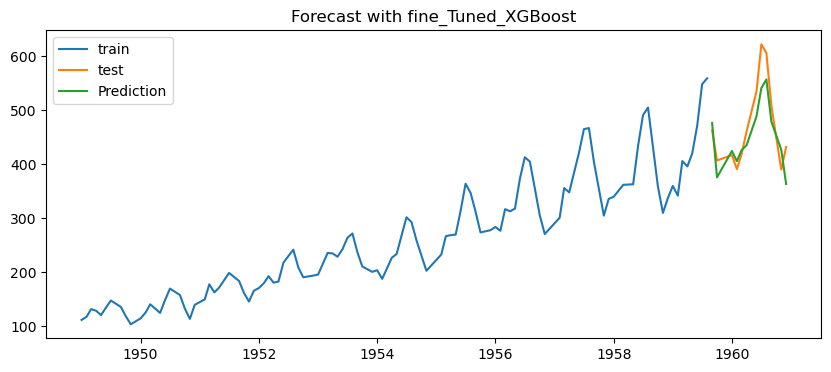

mean absolute error: 34.24
mean absolute percentage error: 7.000000000000001%
r2 score: 0.72
root mean squared error: 40.98


In [23]:
xgb_values= model_evaluator(y_train,y_test,grid_pred, 'fine_Tuned_XGBoost')

In [24]:
xgb_values.to_csv(r'C:\Users\MINE\Desktop\Air passenger prediction\dataset\xgb_metric.csv')

In [25]:
# Final_model

final_model= XGBRegressor(**param)
final_model.fit(df.drop(columns=['#Passengers']), df['#Passengers'])

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8999999999999999, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.2, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.10500000000000001,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=2, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, ...)

In [26]:
future_data= pd.date_range(start= '1961-01-01' , freq='MS', periods=12)
future_data= pd.Series(index= future_data)
future_data.index

DatetimeIndex(['1961-01-01', '1961-02-01', '1961-03-01', '1961-04-01',
               '1961-05-01', '1961-06-01', '1961-07-01', '1961-08-01',
               '1961-09-01', '1961-10-01', '1961-11-01', '1961-12-01'],
              dtype='datetime64[ns]', freq='MS')

In [27]:

def build_exog_row(model, history, future_dates_df, target_col="#Passengers"):
 
    history = history.copy()
    all_exog_rows = []
    all_predictions = []

    for date in future_data.index:

        month_number = date.month
        quarter_number =date.quarter

        lag1  = history.iloc[-1]  if len(history) >= 1  else history.iloc[0]
        lag2  = history.iloc[-2]  if len(history) >= 2  else history.iloc[0]
        lag3  = history.iloc[-3]  if len(history) >= 3  else history.iloc[0]


        last_3_months  = history.iloc[-3:]  if len(history) >= 3  else history
        last_6_months  = history.iloc[-6:]  if len(history) >= 6  else history
        last_12_months = history.iloc[-12:] if len(history) >= 12 else history

        rolling_mean_3  = last_3_months.mean()
        rolling_std_3   = last_3_months.std() if len(last_3_months) > 1 else 0.0

        rolling_mean_6  = last_6_months.mean()
        rolling_std_6   = last_6_months.std() if len(last_6_months) > 1 else 0.0

      

        one_row = pd.DataFrame({
            "month": [month_number],
            "quater": [quarter_number],
            "lag1": [lag1],
            "lag2": [lag2],
            "lag3": [lag3],
            "rolling_mean3": [rolling_mean_3],
            "rolling_std3": [rolling_std_3],
            "rolling_mean6": [rolling_mean_6],
            "rolling_std6": [rolling_std_6],
           
        }, index=[date])

        all_exog_rows.append(one_row)

        prediction = model.predict(one_row)

        if hasattr(prediction, "iloc"):
            predicted_value = float(prediction.iloc[0])
        else:
            predicted_value = float(prediction[0])

        all_predictions.append(predicted_value)

        history.loc[date] = predicted_value

   
    future_exog = pd.concat(all_exog_rows)
    forecast = pd.Series(all_predictions, index=future_data.index, name=target_col)

    return future_exog, forecast

In [28]:
history = df["#Passengers"].ffill()  

future_exog, forecast = build_exog_row(final_model, history, future_data)


In [29]:
forecast

1961-01-01    530.062073
1961-02-01    530.234192
1961-03-01    547.074280
1961-04-01    558.528015
1961-05-01    571.081726
1961-06-01    581.831726
1961-07-01    576.725586
1961-08-01    553.500183
1961-09-01    476.477631
1961-10-01    444.954346
1961-11-01    421.763580
1961-12-01    407.870026
Freq: MS, Name: #Passengers, dtype: float64

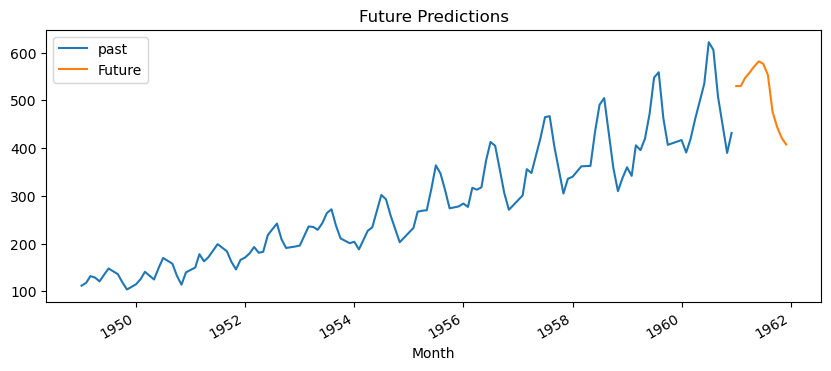

In [30]:
plt.figure(figsize=(10,4))
df['#Passengers'].plot(label='past')
forecast.plot(label='Future')

plt.legend()
plt.title('Future Predictions')
plt.show()

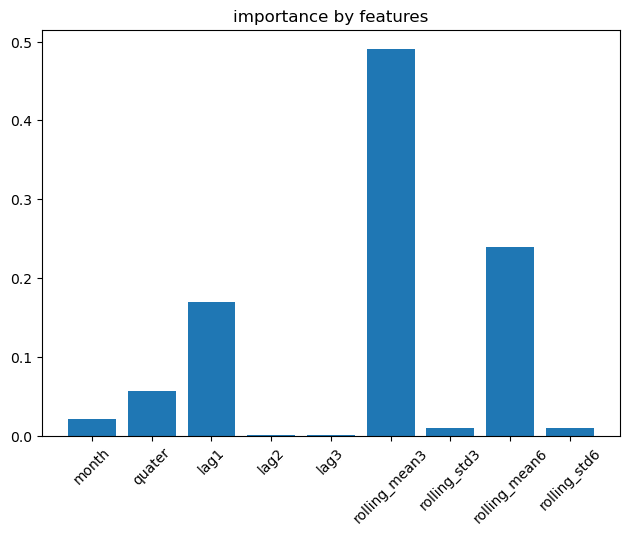

In [31]:
# Feature importance
importances= final_model.feature_importances_
plt.bar( x_train.columns,  importances)

plt.title('importance by features')
plt.tight_layout()
plt.xticks(rotation= 45)
plt.show()

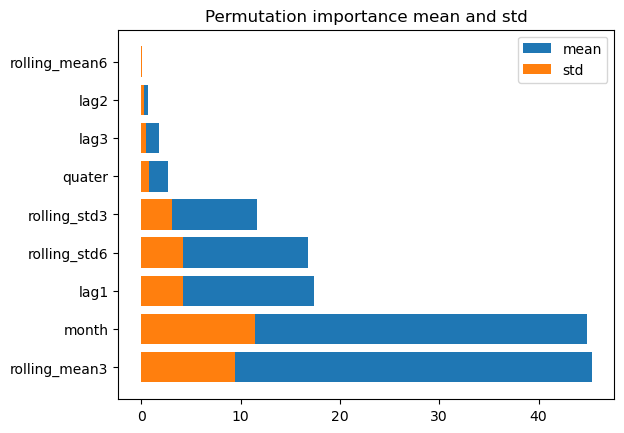

In [32]:
# Permutation Importancve
result_pi= permutation_importance(final_model, x_test, y_test,
                              scoring='neg_mean_absolute_error',
                              n_repeats=30,
                              n_jobs= -1)

features =  {
          'features': x_test.columns,
          'importance_mean': result_pi.importances_mean,
          'importance_std': result_pi.importances_std
        }   
p_imp= pd.DataFrame(features,)
p_imp=p_imp.sort_values('importance_mean', ascending=False)
plt.barh(p_imp['features'], p_imp['importance_mean'], label='mean')
plt.barh(p_imp['features'], p_imp['importance_std'], label='std')

plt.legend()
plt.title('Permutation importance mean and std')
plt.show()

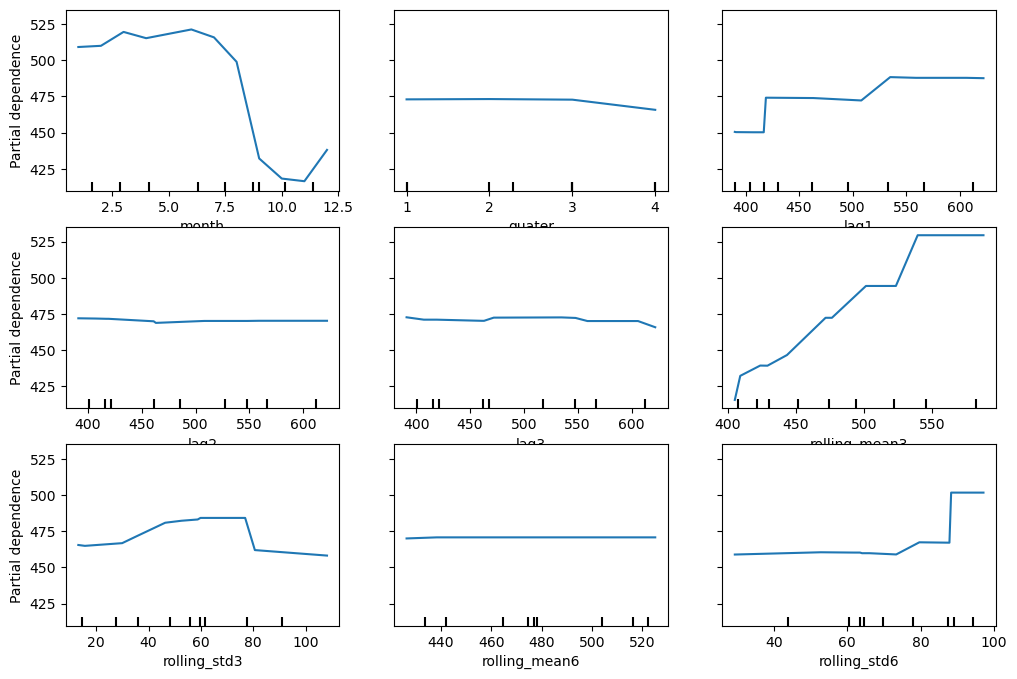

In [33]:
fig,axes= plt.subplots(figsize=(12,8))
PartialDependenceDisplay.from_estimator(final_model, x_test,
                                        kind= 'average',
                                        features= list(x_test.columns),
                                        feature_names= list(x_test.columns),
                                        grid_resolution= 50,
                                        n_cols= 3,
                                        ax= axes)

In [34]:
joblib.dump(final_model, r"C:\Users\MINE\Desktop\Air passenger prediction\models\xgboost.pkl")

['C:\\Users\\MINE\\Desktop\\Air passenger prediction\\models\\xgboost.pkl']